**Goal:** train a network with **no labels**. You will build an **autoencoder** that squeezes each
FashionMNIST image through a narrow **bottleneck** and rebuilds it, look at the 2-D **latent space** it
learns, turn it into a **denoiser**, and finally use its compressed code as a **representation** for
classification. Everything runs on CPU in about fifteen seconds. Pairs with the concept note
[Autoencoders & Representation Learning](l20_concept_autoencoders.qmd).

> **Previously:** L19 -- CNN Architectures & Transfer Learning (reuse labeled features)  |  **Next:** L21 -- Attention Mechanisms

> This page is the read-only view. To run the lab, open the notebook
> (`l20_lab_autoencoders.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

Nobody labeled your images, but you still want useful features. An autoencoder supervises itself: its
target is its own input. Force the signal through a layer far too narrow to carry 784 pixels and the
network has to learn what *matters* -- the structure that lets a few numbers stand in for a whole image.
We will watch that compressed code reconstruct images, separate classes on a 2-D plot it was never told
about, clean up noise, and classify almost as well as the raw pixels.

## Setup

Two cells: the first installs, the second imports, seeds, loads a FashionMNIST subset, and defines two
helpers (train an autoencoder; measure reconstruction MSE).

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships these, so this is effectively a no-op there.
%pip install -q torch torchvision scikit-learn matplotlib
# local, in a terminal (not in the notebook):  uv add torch torchvision scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS + SEEDS + DATA + HELPERS (safe to re-run without re-installing)
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)   # we cap logreg iterations for speed; accuracies are stable

torch.manual_seed(42); np.random.seed(42)

tfm = transforms.ToTensor()                                   # PIL image -> [1, 28, 28] tensor in [0, 1]
train_full = torchvision.datasets.FashionMNIST("data", train=True,  download=True, transform=tfm)
test_full  = torchvision.datasets.FashionMNIST("data", train=False, download=True, transform=tfm)
CLASSES = train_full.classes

def flat_subset(ds, n, seed=42):
    """A seed-locked subset of n images, each flattened to a 784-vector in [0, 1]."""
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(len(ds), generator=g)[:n].tolist()
    X = torch.stack([ds[i][0].view(-1) for i in idx])
    y = torch.tensor([ds[i][1] for i in idx])
    return X, y

Xtr, ytr = flat_subset(train_full, 10000)                     # 10k train, 5k test -- keeps the lab fast
Xte, yte = flat_subset(test_full, 5000)

def train_ae(model, X, epochs=15, noise=0.0, bs=128):
    """Train an autoencoder to reconstruct X (or, if noise>0, to reconstruct X from a noisy copy)."""
    opt = torch.optim.Adam(model.parameters(), lr=1e-3); loss_fn = nn.MSELoss()
    loader = DataLoader(TensorDataset(X), batch_size=bs, shuffle=True,
                        generator=torch.Generator().manual_seed(0))
    curve = []
    for epoch in range(epochs):
        model.train(); running = 0.0
        for (xb,) in loader:
            inp = xb if noise == 0 else (xb + noise * torch.randn_like(xb)).clamp(0, 1)
            opt.zero_grad(); loss = loss_fn(model(inp), xb); loss.backward(); opt.step()
            running += loss.item() * len(xb)
        curve.append(running / len(X))
    return curve

def recon_mse(model, X):
    model.eval()
    with torch.no_grad():
        return nn.MSELoss()(model(X), X).item()

print(f"train {len(Xtr)} / test {len(Xte)} images, each a {Xtr.shape[1]}-vector; {len(CLASSES)} classes")

train 10000 / test 5000 images, each a 784-vector; 10 classes


~~~text
train 10000 / test 5000 images, each a 784-vector; 10 classes
~~~

## Step 1: Build and Train an Autoencoder

An autoencoder is two stacked MLPs. The **encoder** funnels 784 pixels down to a 32-number
**bottleneck**; the **decoder** expands those 32 numbers back to 784. Because the bottleneck is far
smaller than the input (it is **undercomplete**), the network cannot just copy -- it must learn to
compress. The loss is the **reconstruction loss**: the MSE between the output and the input itself, so
no labels are involved.

In [3]:
class AutoEncoder(nn.Module):
    def __init__(self, latent=32):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(784, 256), nn.ReLU(),
                                     nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, latent))
        self.decoder = nn.Sequential(nn.Linear(latent, 64), nn.ReLU(),
                                     nn.Linear(64, 256), nn.ReLU(), nn.Linear(256, 784), nn.Sigmoid())
    def forward(self, x):
        return self.decoder(self.encoder(x))

torch.manual_seed(42)
ae = AutoEncoder(latent=32)
curve = train_ae(ae, Xtr, epochs=15)
print(f"reconstruction loss: {curve[0]:.4f} -> {curve[-1]:.4f}")
print(f"test reconstruction MSE: {recon_mse(ae, Xte):.4f}")

reconstruction loss: 0.0825 -> 0.0176
test reconstruction MSE: 0.0178


~~~text
reconstruction loss: 0.0825 -> 0.0176
test reconstruction MSE: 0.0178
~~~

The 32-number code reconstructs each image at a test MSE of about **0.018**. Look at the originals
against their reconstructions -- a little blurred (32 numbers cannot keep every pixel), but plainly the
same garments:

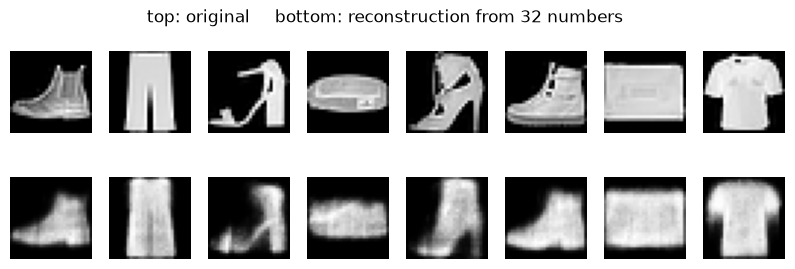

In [4]:
ae.eval()
with torch.no_grad():
    recon = ae(Xte[:8])
plt.figure(figsize=(10, 3))
for i in range(8):
    plt.subplot(2, 8, i + 1); plt.imshow(Xte[i].reshape(28, 28), cmap="gray"); plt.axis("off")
    plt.subplot(2, 8, i + 9); plt.imshow(recon[i].reshape(28, 28), cmap="gray"); plt.axis("off")
plt.suptitle("top: original     bottom: reconstruction from 32 numbers"); plt.show()

## Step 2: Look at the Latent Space

Shrink the bottleneck all the way to **2** numbers and you can plot it. Train a 2-unit autoencoder, then
scatter every test image at its 2-D code, colored by its (unused) class label:

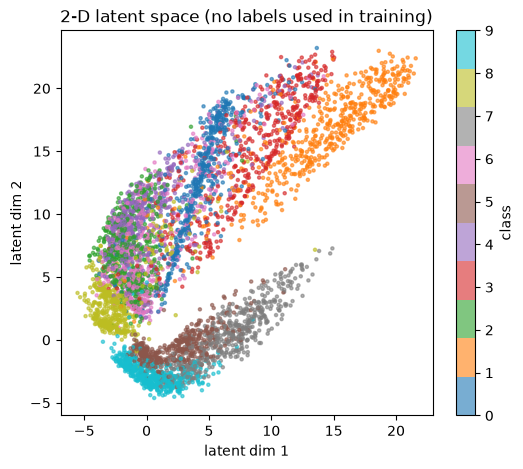

In [5]:
torch.manual_seed(42)
ae2 = AutoEncoder(latent=2)
train_ae(ae2, Xtr, epochs=15)
with torch.no_grad():
    Z2 = ae2.encoder(Xte).numpy()

plt.figure(figsize=(6, 5))
plt.scatter(Z2[:, 0], Z2[:, 1], c=yte.numpy(), cmap="tab10", s=5, alpha=0.6)
plt.colorbar(label="class"); plt.xlabel("latent dim 1"); plt.ylabel("latent dim 2")
plt.title("2-D latent space (no labels used in training)"); plt.show()

The classes fall into distinct regions even though training never saw a label. We can put a number on
that structure: fit a plain logistic-regression classifier on just those **2** latent numbers.

In [6]:
with torch.no_grad():
    Z2tr = ae2.encoder(Xtr).numpy()
acc2 = (LogisticRegression(max_iter=1000).fit(Z2tr, ytr.numpy()).predict(Z2) == yte.numpy()).mean()
print("2-D latent shape:", Z2.shape)
print(f"logistic regression on just 2 latent numbers: {acc2:.4f}  (chance = 0.10)")

2-D latent shape: (5000, 2)
logistic regression on just 2 latent numbers: 0.6396  (chance = 0.10)


~~~text
2-D latent shape: (5000, 2)
logistic regression on just 2 latent numbers: 0.6396  (chance = 0.10)
~~~

Two unsupervised numbers already carry most of the class signal -- a vivid sign that the encoder learned
*meaning*, not pixels.

## Step 3: Turn It Into a Denoiser

A small change makes the autoencoder useful in a new way. Feed it a **noisy** image but ask it to
reconstruct the **clean** one. To minimize that loss the network must learn what the noise is not --
the underlying structure -- so it can rebuild it. This is a **denoising autoencoder**.

In [7]:
torch.manual_seed(42)
dae = AutoEncoder(latent=32)
train_ae(dae, Xtr, epochs=15, noise=0.5)            # train on noisy inputs, clean targets
dae.eval()

torch.manual_seed(123)
noisy = (Xte + 0.5 * torch.randn_like(Xte)).clamp(0, 1)
with torch.no_grad():
    cleaned = dae(noisy)
print(f"noisy-vs-clean    test MSE: {nn.MSELoss()(noisy, Xte).item():.4f}")
print(f"denoised-vs-clean test MSE: {nn.MSELoss()(cleaned, Xte).item():.4f}")

noisy-vs-clean    test MSE: 0.1179
denoised-vs-clean test MSE: 0.0238


~~~text
noisy-vs-clean    test MSE: 0.1179
denoised-vs-clean test MSE: 0.0238
~~~

The noise pushed the images **0.118** away from clean; the autoencoder pulled them back to **0.024**, a
roughly fivefold cut -- on noise it never saw during training. See it on a few examples (noisy, cleaned,
original):

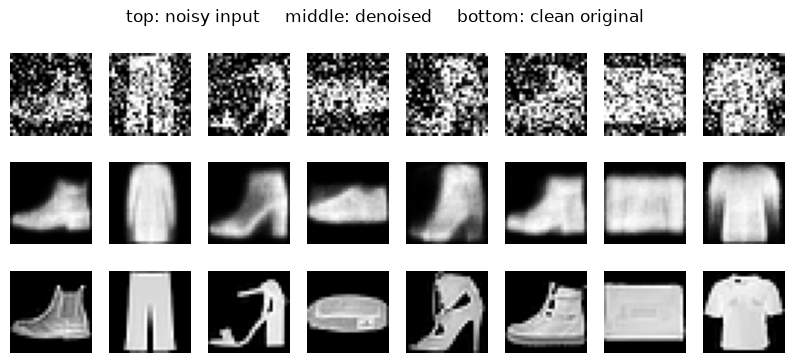

In [8]:
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(3, 8, i + 1);  plt.imshow(noisy[i].reshape(28, 28),   cmap="gray"); plt.axis("off")
    plt.subplot(3, 8, i + 9);  plt.imshow(cleaned[i].reshape(28, 28), cmap="gray"); plt.axis("off")
    plt.subplot(3, 8, i + 17); plt.imshow(Xte[i].reshape(28, 28),     cmap="gray"); plt.axis("off")
plt.suptitle("top: noisy input     middle: denoised     bottom: clean original"); plt.show()

## Step 4: The Latent Code as a Representation

The encoder is a feature extractor learned with no labels -- like L19's pretrained backbone, but trained
on the data itself. Encode every image to its 32-number code and classify *those* with plain logistic
regression (the Unit II model), then compare against classifying the raw 784 pixels:

In [9]:
ae.eval()
with torch.no_grad():
    Ztr, Zte = ae.encoder(Xtr).numpy(), ae.encoder(Xte).numpy()
acc_latent = (LogisticRegression(max_iter=1000).fit(Ztr, ytr.numpy()).predict(Zte) == yte.numpy()).mean()
acc_raw    = (LogisticRegression(max_iter=1000).fit(Xtr.numpy(), ytr.numpy()).predict(Xte.numpy()) == yte.numpy()).mean()
print(f"logistic regression on 32 latent features: {acc_latent:.4f}")
print(f"logistic regression on 784 raw pixels:     {acc_raw:.4f}")

logistic regression on 32 latent features: 0.7916
logistic regression on 784 raw pixels:     0.8302


~~~text
logistic regression on 32 latent features: 0.7916
logistic regression on 784 raw pixels:     0.8302
~~~

Thirty-two unsupervised numbers classify at **0.79**, against **0.83** for all 784 pixels -- a 24x
compression that keeps most of the signal, and the encoder never saw a single label. That is the point
of **representation learning**: features learned from the data itself are compact and reusable.

In [10]:
# Your turn (warm-up): the encoder compresses 784 pixels to the bottleneck size. Predict the
# compression ratio, then check it. Uncomment and fill the blank:
# ratio = ____                                        # 784 / 32
# assert round(ratio, 1) == round(784 / ae.encoder[-1].out_features, 1)
# print(f"compression ratio: {ratio:.1f}x")

The blank is `784 / 32`, which is `24.5` -- the encoder's last layer (`ae.encoder[-1]`) outputs 32
features, so each image is squeezed to one twenty-fourth of its pixels.

## Your Turn

### Exercise 1 -- The bottleneck is a dial

The latent size trades compression against fidelity. Re-run Step 1's autoencoder with `latent` set to 8,
16, 32, and 64, and for each report the test reconstruction MSE (`recon_mse`) and the downstream
logistic-regression accuracy on the latent code (as in Step 4). Which way does each move?

**Hint:** loop over the sizes; for each, `torch.manual_seed(42)`, build `AutoEncoder(latent=L)`, train
with `train_ae(..., epochs=15)`, then encode and fit `LogisticRegression(max_iter=1000)`. Re-seed before
each build so the runs are comparable.

In [11]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
latent  8 -> test MSE 0.0186, downstream accuracy 0.7498
latent 16 -> test MSE 0.0182, downstream accuracy 0.7768
latent 32 -> test MSE 0.0178, downstream accuracy 0.7916
latent 64 -> test MSE 0.0184, downstream accuracy 0.8022
~~~

Downstream accuracy climbs steadily with the bottleneck (0.75 -> 0.80) -- more latent room means a richer
representation. Reconstruction MSE barely moves past 16 (about 0.018): the images are already easy to
rebuild, so the extra capacity buys *representation* quality more than pixel fidelity. The bottleneck is
the autoencoder's compression dial, and bigger is not automatically better -- past some point you are
just storing pixels again.
</details>

### Exercise 2 -- Heavier noise

Retrain the denoising autoencoder (Step 3) with a stronger noise level, `noise=1.0` instead of 0.5, and
compare the denoised MSE. Does it still clean the images?

**Hint:** `torch.manual_seed(42)`, build a fresh `AutoEncoder(32)`, `train_ae(..., noise=1.0)`, then
build `noisy = (Xte + 1.0 * torch.randn_like(Xte)).clamp(0, 1)` (re-seed `torch.manual_seed(123)` first,
as in Step 3) and measure the noisy and denoised MSE against `Xte`.

In [12]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
noisy-vs-clean    test MSE: 0.2342
denoised-vs-clean test MSE: 0.0309
~~~

At `noise=1.0` the corruption is twice as bad (0.234 vs 0.118), and the autoencoder still pulls it back
to about 0.031 -- a little worse than the 0.024 it managed at `noise=0.5`, because heavier noise hides
more of the signal, but it is still a large, useful cut. A denoiser is only as good as the structure it
learned to trust.
</details>

## Summary

- An **autoencoder** trains with **no labels**: its target is its own input. The **encoder** squeezes
  784 pixels to a 32-number **bottleneck**, the **decoder** rebuilds them, and the **reconstruction
  loss** (MSE) reached about **0.018** -- recognizable reconstructions from 32 numbers.
- Because the bottleneck is **undercomplete**, the net learns structure, not a copy. A **2-D** latent
  space separated the classes with **no labels** (logistic regression on 2 numbers: **0.64**).
- A **denoising autoencoder** trained on corrupted inputs cut test MSE from **0.118** (noisy) to
  **0.024** (denoised) on noise it never saw.
- The latent code is a **representation**: 32 unsupervised features classified at **0.79** vs **0.83**
  for all 784 raw pixels -- a 24x compression keeping most of the signal. The bottleneck size is a dial
  (Ex1: 0.75 -> 0.80 as it widens).
- Next (L21): instead of compressing a fixed input, **attention** lets a model decide which parts of its
  input to focus on -- the idea behind Transformers.